In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)
from catboost import CatBoostRegressor
import requests

from tabulate import tabulate
from datetime import timedelta

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, explained_variance_score
from sklearn.model_selection import train_test_split
%matplotlib inline

In [2]:
df=pd.read_csv("/kaggle/input/dutch-energy-supplier-load-forecasting-challenge/train_expanded.csv")

In [3]:
df.head()

,timestamp_utc,net_load_kwh
0,2025-05-08 22:00:00,-317.513
1,2025-05-08 22:15:00,-308.916
2,2025-05-08 22:30:00,-299.968
3,2025-05-08 22:45:00,-289.338
4,2025-05-08 23:00:00,-275.887


In [4]:
df.isnull().sum()

timestamp_utc    0
net_load_kwh     0
dtype: int64

In [5]:
df.shape

(11048, 2)

In [6]:
df["timestamp_utc"]=pd.to_datetime(df["timestamp_utc"],utc=True)


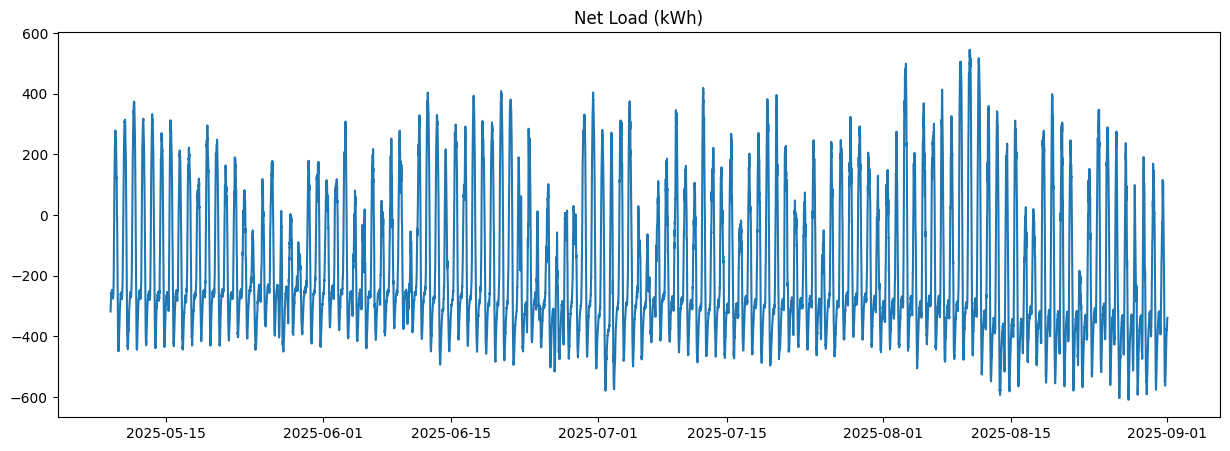

In [7]:
plt.figure(figsize=(15, 5))
plt.plot(df['timestamp_utc'], df['net_load_kwh'])
plt.title('Net Load (kWh)')
plt.show()

In [8]:
def fetch_weather(start_date, end_date, lat=52.3676, lon=4.9041):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        'latitude': lat,
        'longitude': lon,
        'start_date': start_date.strftime('%Y-%m-%d'),
        'end_date': end_date.strftime('%Y-%m-%d'),
        'hourly': 'temperature_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,shortwave_radiation',
        'timezone': 'UTC'
    }
    response = requests.get(url, params=params)
    data = response.json()
    
    # Error handling
    if response.status_code != 200 or 'hourly' not in data:
        raise ValueError("API request failed or invalid response")
    
    # Create hourly DF with timestamp_utc and weather features
    weather_df = pd.DataFrame({
        'timestamp_utc': pd.to_datetime(data['hourly']['time'], utc=True),
        'temperature_2m': data['hourly']['temperature_2m'],
        'apparent_temperature': data['hourly']['apparent_temperature'],
        'precipitation': data['hourly']['precipitation'],
        'cloud_cover': data['hourly']['cloud_cover'],
        'wind_speed_10m': data['hourly']['wind_speed_10m'],
        'shortwave_radiation': data['hourly']['shortwave_radiation']
    })
    
    # Interpolate to 15-min intervals
    weather_df = weather_df.set_index('timestamp_utc').resample('15T').interpolate(method='linear').ffill().reset_index()
    
    return weather_df

In [9]:
# def create_features(df):
#     df['year'] = df['timestamp_utc'].dt.year
#     df['month'] = df['timestamp_utc'].dt.month
#     df['day'] = df['timestamp_utc'].dt.day
#     df['hour'] = df['timestamp_utc'].dt.hour
#     df['minute'] = df['timestamp_utc'].dt.minute
#     df['dayofweek'] = df['timestamp_utc'].dt.dayofweek
#     df['dayofyear'] = df['timestamp_utc'].dt.dayofyear
#     df['weekofyear'] = df['timestamp_utc'].dt.isocalendar().week.astype(int)
#     df['quarter'] = df['timestamp_utc'].dt.quarter
#     df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
#     df['is_month_start'] = df['timestamp_utc'].dt.is_month_start.astype(int)
#     df['is_month_end'] = df['timestamp_utc'].dt.is_month_end.astype(int)
#     df['is_quarter_start'] = df['timestamp_utc'].dt.is_quarter_start.astype(int)
#     df['is_quarter_end'] = df['timestamp_utc'].dt.is_quarter_end.astype(int)
#     df['is_year_start'] = df['timestamp_utc'].dt.is_year_start.astype(int)
#     df['is_year_end'] = df['timestamp_utc'].dt.is_year_end.astype(int)

#     df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
#     df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
#     df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
#     df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
#     df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
#     df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
#     df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
#     df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)
#     df['weekofyear_sin'] = np.sin(2 * np.pi * df['weekofyear'] / 52)
#     df['weekofyear_cos'] = np.cos(2 * np.pi * df['weekofyear'] / 52)

#     weather_cols = ['temperature_2m','apparent_temperature','precipitation','cloud_cover','wind_speed_10m','shortwave_radiation']
#     for col in weather_cols:
#         if col in df.columns:
#             df[f'{col}_lag0'] = df[col]
#             df[f'{col}_lag4'] = df[col].shift(4)

#     num_cols = df.select_dtypes(include=[np.number]).columns
#     for col in num_cols:
#         df[col].fillna(df[col].mean(), inplace=True)

#     return df


In [10]:
import pandas as pd
import numpy as np
import holidays

def create_features(df):
    df = df.copy()
    
    # Time features from timestamp_utc
    df['hour'] = df['timestamp_utc'].dt.hour
    df['dayofweek'] = df['timestamp_utc'].dt.dayofweek
    df['month'] = df['timestamp_utc'].dt.month
    df['dayofyear'] = df['timestamp_utc'].dt.dayofyear
    df['weekofyear'] = df['timestamp_utc'].dt.isocalendar().week
    df['quarter'] = df['timestamp_utc'].dt.quarter
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_business_hour'] = ((df['hour'] >= 8) & (df['hour'] <= 18)).astype(int)  # 8 AM to 6 PM
    df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)  # 10 PM to 5 AM
    
    # Dutch holidays
    nl_holidays = holidays.Netherlands(years=df['timestamp_utc'].dt.year.unique())
    df['is_holiday'] = df['timestamp_utc'].dt.date.isin(nl_holidays).astype(int)
    
    # Cyclical encodings
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
    df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)
    
    # Weather features
    weather_cols = ['temperature_2m', 'apparent_temperature', 'precipitation', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
    for col in weather_cols:
        if col in df.columns:
            # Rolling statistics (1h, 2h)
            df[f'{col}_roll_mean_4'] = df[col].rolling(window=4, min_periods=1).mean()  # 1h
            df[f'{col}_roll_std_8'] = df[col].rolling(window=8, min_periods=1).std()   # 2h
            # Differences (1h, 3h)
            df[f'{col}_diff_4'] = df[col].diff(4)   # 1h
            df[f'{col}_diff_12'] = df[col].diff(12)  # 3h
            # Polynomial terms for key variables
            if col in ['temperature_2m', 'shortwave_radiation']:
                df[f'{col}_squared'] = df[col] ** 2
                df[f'{col}_sqrt'] = np.sqrt(np.maximum(df[col], 0))  # Avoid negative sqrt
    
    # Weather interactions
    if all(col in df.columns for col in ['temperature_2m', 'shortwave_radiation']):
        df['temp_solar_interaction'] = df['temperature_2m'] * df['shortwave_radiation']
        df['temp_solar_ratio'] = df['temperature_2m'] / (df['shortwave_radiation'] + 1e-5)
    if all(col in df.columns for col in ['precipitation', 'cloud_cover']):
        df['precip_cloud_ratio'] = df['precipitation'] / (df['cloud_cover'] + 1e-5)
    if all(col in df.columns for col in ['temperature_2m', 'apparent_temperature']):
        df['temp_ratio'] = df['apparent_temperature'] / (df['temperature_2m'] + 1e-5)
    
    # Time-weather interactions
    if 'temperature_2m' in df.columns:
        df['hour_x_temp'] = df['hour'] * df['temperature_2m']
        df['dayofweek_x_temp'] = df['dayofweek'] * df['temperature_2m']
        df['is_business_hour_x_temp'] = df['is_business_hour'] * df['temperature_2m']
    if 'shortwave_radiation' in df.columns:
        df['hour_x_solar'] = df['hour'] * df['shortwave_radiation']
        df['is_night_x_solar'] = df['is_night'] * df['shortwave_radiation']
    
    # Seasonal category
    df['season'] = pd.cut(df['month'], bins=[0, 3, 6, 9, 12], labels=['winter', 'spring', 'summer', 'autumn'])
    df = pd.get_dummies(df, columns=['season'], prefix='season', drop_first=True)
    
    # Fill missing values
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        df[col].fillna(df[col].mean(), inplace=True)
    
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        if not df[col].mode().empty:
            df[col].fillna(df[col].mode()[0], inplace=True)
    
    return df

In [11]:
start_date = df['timestamp_utc'].min().floor('D')
end_date = df['timestamp_utc'].max().ceil('D')
weather_full = fetch_weather(start_date, end_date)
df = df.merge(weather_full, on='timestamp_utc', how='left')
df = create_features(df)
df.drop(columns=['timestamp_utc'], inplace=True)

In [12]:
df.head()

,net_load_kwh,temperature_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,shortwave_radiation,hour,dayofweek,month,dayofyear,weekofyear,quarter,is_weekend,is_business_hour,is_night,is_holiday,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,month_sin,month_cos,dayofyear_sin,dayofyear_cos,temperature_2m_roll_mean_4,temperature_2m_roll_std_8,temperature_2m_diff_4,temperature_2m_diff_12,temperature_2m_squared,temperature_2m_sqrt,apparent_temperature_roll_mean_4,apparent_temperature_roll_std_8,apparent_temperature_diff_4,apparent_temperature_diff_12,precipitation_roll_mean_4,precipitation_roll_std_8,precipitation_diff_4,precipitation_diff_12,cloud_cover_roll_mean_4,cloud_cover_roll_std_8,cloud_cover_diff_4,cloud_cover_diff_12,wind_speed_10m_roll_mean_4,wind_speed_10m_roll_std_8,wind_speed_10m_diff_4,wind_speed_10m_diff_12,shortwave_radiation_roll_mean_4,shortwave_radiation_roll_std_8,shortwave_radiation_diff_4,shortwave_radiation_diff_12,shortwave_radiation_squared,shortwave_radiation_sqrt,temp_solar_interaction,temp_solar_ratio,precip_cloud_ratio,temp_ratio,hour_x_temp,dayofweek_x_temp,is_business_hour_x_temp,hour_x_solar,is_night_x_solar,season_spring,season_summer,season_autumn
0,-317.513,11.50,8.2,0.0,11.0,10.700,0.0,22,3,5,128,19,2,0,0,1,0,-0.500000,0.866025,0.433884,-0.900969,0.5,-0.866025,0.807371,-0.590044,11.500,0.398004,0.00211,0.007512,132.2500,3.391165,8.2,0.420635,0.003563,0.011721,0.0,0.049807,3.669245e-19,-2.414403e-19,11.00,8.143954,0.02979,0.087849,10.7000,0.696710,-0.001974,-0.005133,0.0,38.52511,0.0,0.0,0.0,0.0,0.0,1150000.0,0.0,0.713043,253.0,34.50,0.0,0.0,0.0,True,False,False
1,-308.916,11.25,8.0,0.0,15.5,10.375,0.0,22,3,5,128,19,2,0,0,1,0,-0.500000,0.866025,0.433884,-0.900969,0.5,-0.866025,0.807371,-0.590044,11.375,0.176777,0.00211,0.007512,126.5625,3.354102,8.1,0.141421,0.003563,0.011721,0.0,0.000000,3.669245e-19,-2.414403e-19,13.25,3.181981,0.02979,0.087849,10.5375,0.229810,-0.001974,-0.005133,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,1125000.0,0.0,0.711110,247.5,33.75,0.0,0.0,0.0,True,False,False
2,-299.968,11.00,7.8,0.0,20.0,10.050,0.0,22,3,5,128,19,2,0,0,1,0,-0.500000,0.866025,0.433884,-0.900969,0.5,-0.866025,0.807371,-0.590044,11.250,0.250000,0.00211,0.007512,121.0000,3.316625,8.0,0.200000,0.003563,0.011721,0.0,0.000000,3.669245e-19,-2.414403e-19,15.50,4.500000,0.02979,0.087849,10.3750,0.325000,-0.001974,-0.005133,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,1100000.0,0.0,0.709090,242.0,33.00,0.0,0.0,0.0,True,False,False
3,-289.338,10.75,7.6,0.0,24.5,9.725,0.0,22,3,5,128,19,2,0,0,1,0,-0.500000,0.866025,0.433884,-0.900969,0.5,-0.866025,0.807371,-0.590044,11.125,0.322749,0.00211,0.007512,115.5625,3.278719,7.9,0.258199,0.003563,0.011721,0.0,0.000000,3.669245e-19,-2.414403e-19,17.75,5.809475,0.02979,0.087849,10.2125,0.419573,-0.001974,-0.005133,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,1075000.0,0.0,0.706976,236.5,32.25,0.0,0.0,0.0,True,False,False
4,-275.887,10.50,7.4,0.0,29.0,9.400,0.0,23,3,5,128,19,2,0,0,1,0,-0.258819,0.965926,0.433884,-0.900969,0.5,-0.866025,0.807371,-0.590044,10.875,0.395285,-1.00000,0.007512,110.2500,3.240370,7.7,0.316228,-0.800000,0.011721,0.0,0.000000,0.000000e+00,-2.414403e-19,22.25,7.115125,18.00000,0.087849,9.8875,0.513870,-1.300000,-0.005133,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,1050000.0,0.0,0.704761,241.5,31.50,0.0,0.0,0.0,True,False,False


In [13]:
df.shape

(11048, 65)

In [14]:
X = df.drop(columns=['net_load_kwh'])
y = df['net_load_kwh']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [16]:
X_train.shape,X_test.shape

((8838, 64), (2210, 64))

In [17]:
model = CatBoostRegressor(iterations=1000,learning_rate=0.5,depth=6,loss_function='RMSE',random_seed=42,verbose=200)
model.fit(X_train, y_train)

0:	learn: 130.7344685	total: 61.4ms	remaining: 1m 1s
200:	learn: 12.4046822	total: 1.53s	remaining: 6.09s
400:	learn: 7.2139843	total: 2.85s	remaining: 4.26s
600:	learn: 4.8695160	total: 4.18s	remaining: 2.78s
800:	learn: 3.4219903	total: 5.52s	remaining: 1.37s
999:	learn: 2.5158788	total: 6.84s	remaining: 0us


In [18]:
def compute_metrics(y_true, y_pred, mean_target):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    nmae = (mae / mean_target) * 100
    nrmse = (rmse / mean_target) * 100
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Explained Variance': evs,
        'MAPE (%)': mape,
        'NMAE (%)': nmae,
        'NRMSE (%)': nrmse
    }

mean_target = y_test.mean()
y_pred_test = model.predict(X_test)
metrics = compute_metrics(y_test, y_pred_test, mean_target)
print(tabulate([[m, f"{v:.4f}"] for m, v in metrics.items()], headers=["Metric", "Value"], tablefmt="grid"))


+--------------------+------------+
| Metric             |      Value |
+====================+============+
| MAE                |    77.2638 |
+--------------------+------------+
| MSE                | 10989.9    |
+--------------------+------------+
| RMSE               |   104.833  |
+--------------------+------------+
| R2                 |     0.8449 |
+--------------------+------------+
| Explained Variance |     0.8938 |
+--------------------+------------+
| MAPE (%)           |   142.175  |
+--------------------+------------+
| NMAE (%)           |   -33.9895 |
+--------------------+------------+
| NRMSE (%)          |   -46.1174 |
+--------------------+------------+


# Predict ON Test Data

In [19]:
test_df=pd.read_csv("/kaggle/input/dutch-energy-supplier-load-forecasting-challenge/test_new.csv")

In [20]:
test_df.head()

,row_id,timestamp_utc
0,0,2025-09-01 00:00:00
1,1,2025-09-01 00:15:00
2,2,2025-09-01 00:30:00
3,3,2025-09-01 00:45:00
4,4,2025-09-01 01:00:00


In [21]:
test_df.shape

(2296, 2)

In [22]:
test_df.isnull().sum()

row_id           0
timestamp_utc    0
dtype: int64

In [23]:
Id=test_df.row_id

In [24]:
test_df['timestamp_utc'] = pd.to_datetime(test_df['timestamp_utc'], utc=True)

In [25]:
start_date = test_df['timestamp_utc'].min().floor('D')
end_date = test_df['timestamp_utc'].max().ceil('D')
weather_full = fetch_weather(start_date, end_date)
test_df = test_df.merge(weather_full, on='timestamp_utc', how='left')
test_df = create_features(test_df)
test_df.drop(columns=['timestamp_utc',"row_id"], inplace=True)

In [26]:
y_pred=model.predict(test_df)
submission = pd.DataFrame({'row_id': Id, 'net_load_kwh': y_pred})
submission.to_csv('submission.csv', index=False)

# Create Model 2

In [27]:
df=pd.read_csv("/kaggle/input/dutch-energy-supplier-load-forecasting-challenge/train_expanded.csv")

In [28]:
df.head()

,timestamp_utc,net_load_kwh
0,2025-05-08 22:00:00,-317.513
1,2025-05-08 22:15:00,-308.916
2,2025-05-08 22:30:00,-299.968
3,2025-05-08 22:45:00,-289.338
4,2025-05-08 23:00:00,-275.887


In [29]:
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)

In [30]:
def fetch_weather(start_date, end_date, lat=52.3676, lon=4.9041):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        'latitude': lat,
        'longitude': lon,
        'start_date': start_date.strftime('%Y-%m-%d'),
        'end_date': end_date.strftime('%Y-%m-%d'),
        'hourly': 'temperature_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,shortwave_radiation',
        'timezone': 'UTC'
    }
    response = requests.get(url, params=params)
    data = response.json()
    
    weather_df = pd.DataFrame({
        'timestamp_utc': pd.to_datetime(data['hourly']['time'], utc=True),
        'temperature_2m': data['hourly']['temperature_2m'],
        'apparent_temperature': data['hourly']['apparent_temperature'],
        'precipitation': data['hourly']['precipitation'],
        'cloud_cover': data['hourly']['cloud_cover'],
        'wind_speed_10m': data['hourly']['wind_speed_10m'],
        'shortwave_radiation': data['hourly']['shortwave_radiation']
    })
    
    weather_df.set_index('timestamp_utc', inplace=True)
    weather_15min = weather_df.resample('15T').interpolate(method='linear').ffill().reset_index()
    
    return weather_15min

weather_df = fetch_weather(df['timestamp_utc'].min(), df['timestamp_utc'].max())
df = df.merge(weather_df, on='timestamp_utc', how='left')

In [31]:
def add_time_features(new_df, timestamp_col='timestamp_utc'):
    new_df = new_df.copy()
    new_df['hour'] = new_df[timestamp_col].dt.hour
    new_df['minute'] = new_df[timestamp_col].dt.minute
    new_df['dayofweek'] = new_df[timestamp_col].dt.dayofweek
    new_df['is_weekend'] = new_df['dayofweek'].isin([5, 6]).astype(int)
    new_df['month'] = new_df[timestamp_col].dt.month
    new_df['quarter'] = new_df[timestamp_col].dt.quarter
    new_df['hour_sin'] = np.sin(2 * np.pi * new_df['hour'] / 24)
    new_df['hour_cos'] = np.cos(2 * np.pi * new_df['hour'] / 24)
    new_df['dow_sin'] = np.sin(2 * np.pi * new_df['dayofweek'] / 7)
    new_df['dow_cos'] = np.cos(2 * np.pi * new_df['dayofweek'] / 7)
    return new_df

df=add_time_features(df,"timestamp_utc")

In [32]:
def add_weather_features(new_df, weather_cols=['temperature_2m','apparent_temperature','precipitation','cloud_cover','wind_speed_10m','shortwave_radiation']):
    new_df = new_df.copy()
    windows = [12, 24, 48, 96]
    lags = [1, 4, 12]
    
    for col in weather_cols:
        for w in windows:
            new_df[f'{col}_rollmean_{w}'] = new_df[col].rolling(w, min_periods=1).mean()
            new_df[f'{col}_rollstd_{w}'] = new_df[col].rolling(w, min_periods=1).std()
        for lag in lags:
            new_df[f'{col}_lag_{lag}'] = new_df[col].shift(lag)
    
    new_df['temp_x_cloud'] = new_df['temperature_2m'] * new_df['cloud_cover']
    new_df['temp_x_wind'] = new_df['temperature_2m'] * new_df['wind_speed_10m']
    
    return new_df

df = add_weather_features(df)
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [33]:
df.drop(columns=["timestamp_utc"],axis=1,inplace=True)

In [34]:
df.head()

,net_load_kwh,temperature_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,shortwave_radiation,hour,minute,dayofweek,is_weekend,month,quarter,hour_sin,hour_cos,dow_sin,dow_cos,temperature_2m_rollmean_12,temperature_2m_rollstd_12,temperature_2m_rollmean_24,temperature_2m_rollstd_24,temperature_2m_rollmean_48,temperature_2m_rollstd_48,temperature_2m_rollmean_96,temperature_2m_rollstd_96,temperature_2m_lag_1,temperature_2m_lag_4,temperature_2m_lag_12,apparent_temperature_rollmean_12,apparent_temperature_rollstd_12,apparent_temperature_rollmean_24,apparent_temperature_rollstd_24,apparent_temperature_rollmean_48,apparent_temperature_rollstd_48,apparent_temperature_rollmean_96,apparent_temperature_rollstd_96,apparent_temperature_lag_1,apparent_temperature_lag_4,apparent_temperature_lag_12,precipitation_rollmean_12,precipitation_rollstd_12,precipitation_rollmean_24,precipitation_rollstd_24,precipitation_rollmean_48,precipitation_rollstd_48,precipitation_rollmean_96,precipitation_rollstd_96,precipitation_lag_1,precipitation_lag_4,precipitation_lag_12,cloud_cover_rollmean_12,cloud_cover_rollstd_12,cloud_cover_rollmean_24,cloud_cover_rollstd_24,cloud_cover_rollmean_48,cloud_cover_rollstd_48,cloud_cover_rollmean_96,cloud_cover_rollstd_96,cloud_cover_lag_1,cloud_cover_lag_4,cloud_cover_lag_12,wind_speed_10m_rollmean_12,wind_speed_10m_rollstd_12,wind_speed_10m_rollmean_24,wind_speed_10m_rollstd_24,wind_speed_10m_rollmean_48,wind_speed_10m_rollstd_48,wind_speed_10m_rollmean_96,wind_speed_10m_rollstd_96,wind_speed_10m_lag_1,wind_speed_10m_lag_4,wind_speed_10m_lag_12,shortwave_radiation_rollmean_12,shortwave_radiation_rollstd_12,shortwave_radiation_rollmean_24,shortwave_radiation_rollstd_24,shortwave_radiation_rollmean_48,shortwave_radiation_rollstd_48,shortwave_radiation_rollmean_96,shortwave_radiation_rollstd_96,shortwave_radiation_lag_1,shortwave_radiation_lag_4,shortwave_radiation_lag_12,temp_x_cloud,temp_x_wind
0,-317.513,11.50,8.2,0.0,11.0,10.700,0.0,22,0,3,0,5,2,-0.500000,0.866025,0.433884,-0.900969,11.500,0.575326,11.500,1.071715,11.500,1.875512,11.500,2.517942,17.558995,17.559037,17.559265,8.2,0.602036,8.2,1.095880,8.2,1.869595,8.2,2.524410,16.855871,16.855768,16.854893,0.0,0.06352,0.0,0.090854,0.0,0.122549,0.0,0.157537,0.088257,0.088265,0.088329,11.00,10.979290,11.00,16.844985,11.00,23.270415,11.00,28.971356,53.032639,53.028386,52.994337,10.7000,0.953982,10.7000,1.568721,10.7000,2.418233,10.7000,3.207658,10.879864,10.880496,10.884967,0.0,55.561629,0.0,104.63219,0.0,190.985229,0.0,255.211575,243.684563,243.706628,243.883291,126.500,123.05000
1,-308.916,11.25,8.0,0.0,15.5,10.375,0.0,22,15,3,0,5,2,-0.500000,0.866025,0.433884,-0.900969,11.375,0.176777,11.375,0.176777,11.375,0.176777,11.375,0.176777,11.500000,17.559037,17.559265,8.1,0.141421,8.1,0.141421,8.1,0.141421,8.1,0.141421,8.200000,16.855768,16.854893,0.0,0.00000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.088265,0.088329,13.25,3.181981,13.25,3.181981,13.25,3.181981,13.25,3.181981,11.000000,53.028386,52.994337,10.5375,0.229810,10.5375,0.229810,10.5375,0.229810,10.5375,0.229810,10.700000,10.880496,10.884967,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.000000,0.000000,243.706628,243.883291,174.375,116.71875
2,-299.968,11.00,7.8,0.0,20.0,10.050,0.0,22,30,3,0,5,2,-0.500000,0.866025,0.433884,-0.900969,11.250,0.250000,11.250,0.250000,11.250,0.250000,11.250,0.250000,11.250000,17.559037,17.559265,8.0,0.200000,8.0,0.200000,8.0,0.200000,8.0,0.200000,8.000000,16.855768,16.854893,0.0,0.00000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.088265,0.088329,15.50,4.500000,15.50,4.500000,15.50,4.500000,15.50,4.500000,15.500000,53.028386,52.994337,10.3750,0.325000,10.3750,0.325000,10.3750,0.325000,10.3750,0.325000,10.375000,10.880496,10.884967,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.000000,0.000000,243.706628,243.883291,220.000,110.55000
3,-289.338,10.75,7.6,0.0,24.5,9.725,0.0,22,45,3,0,5,2,-0.500000,0.866025,0.433884,-0.900969,11.125,0.322749,11.125,0.322749,11.125,0.32

In [35]:
df.shape

(11048, 85)

In [36]:
target_col = 'net_load_kwh'
feature_cols = [col for col in df.columns if col not in ['timestamp_utc', target_col]]
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [37]:
X_train.shape

(8838, 84)

In [38]:
model = CatBoostRegressor(iterations=2000,learning_rate=0.1,depth=6,loss_function='MAE',eval_metric='MAE',random_seed=42,verbose=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

0:	learn: 152.6525009	total: 15.4ms	remaining: 30.8s
100:	learn: 26.2131843	total: 1.07s	remaining: 20.2s
200:	learn: 19.6465808	total: 2.11s	remaining: 18.9s
300:	learn: 15.8222554	total: 3.15s	remaining: 17.8s
400:	learn: 13.4652762	total: 4.2s	remaining: 16.7s
500:	learn: 12.1048557	total: 5.24s	remaining: 15.7s
600:	learn: 10.9952249	total: 6.3s	remaining: 14.7s
700:	learn: 10.1743900	total: 7.35s	remaining: 13.6s
800:	learn: 9.4875192	total: 8.42s	remaining: 12.6s
900:	learn: 8.9017955	total: 9.46s	remaining: 11.5s
1000:	learn: 8.4822200	total: 10.6s	remaining: 10.6s
1100:	learn: 8.0517075	total: 11.6s	remaining: 9.49s
1200:	learn: 7.7045685	total: 12.7s	remaining: 8.43s
1300:	learn: 7.3989846	total: 13.8s	remaining: 7.39s
1400:	learn: 7.1085173	total: 14.8s	remaining: 6.32s
1500:	learn: 6.8529702	total: 15.8s	remaining: 5.27s
1600:	learn: 6.6426490	total: 16.9s	remaining: 4.21s
1700:	learn: 6.4549556	total: 18s	remaining: 3.16s
1800:	learn: 6.2795475	total: 19s	remaining: 2.1s
19

In [39]:
def nrmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred)) / (y_true.max() - y_true.min())

def nmae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred) / (y_true.max() - y_true.min())

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def r2(y_true, y_pred):
    return r2_score(y_true, y_pred)

print(f"NRMSE: {nrmse(y_test, y_pred):.4f}")
print(f"NMAE: {nmae(y_test, y_pred):.4f}")
print(f"MAPE: {mape(y_test, y_pred):.2f}%")
print(f"RMSE: {rmse(y_test, y_pred):.4f}")
print(f"MAE: {mae(y_test, y_pred):.4f}")
print(f"R²: {r2(y_test, y_pred):.4f}")

NRMSE: 0.0893
NMAE: 0.0709
MAPE: 138.86%
RMSE: 103.0147
MAE: 81.7803
R²: 0.8503


In [40]:
test_df=pd.read_csv("/kaggle/input/dutch-energy-supplier-load-forecasting-challenge/test_new.csv")

In [41]:
Id=test_df.row_id

In [42]:
test_df['timestamp_utc'] = pd.to_datetime(test_df['timestamp_utc'], utc=True)

weather_df = fetch_weather(test_df['timestamp_utc'].min(), test_df['timestamp_utc'].max())
test_df = test_df.merge(weather_df, on='timestamp_utc', how='left')
test_df=add_time_features(test_df,"timestamp_utc")

test_df = add_weather_features(test_df)
numeric_cols = test_df.select_dtypes(include=np.number).columns
test_df[numeric_cols] = test_df[numeric_cols].fillna(test_df[numeric_cols].mean())

In [43]:
test_df.head()

,row_id,timestamp_utc,temperature_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,shortwave_radiation,hour,minute,dayofweek,is_weekend,month,quarter,hour_sin,hour_cos,dow_sin,dow_cos,temperature_2m_rollmean_12,temperature_2m_rollstd_12,temperature_2m_rollmean_24,temperature_2m_rollstd_24,temperature_2m_rollmean_48,temperature_2m_rollstd_48,temperature_2m_rollmean_96,temperature_2m_rollstd_96,temperature_2m_lag_1,temperature_2m_lag_4,temperature_2m_lag_12,apparent_temperature_rollmean_12,apparent_temperature_rollstd_12,apparent_temperature_rollmean_24,apparent_temperature_rollstd_24,apparent_temperature_rollmean_48,apparent_temperature_rollstd_48,apparent_temperature_rollmean_96,apparent_temperature_rollstd_96,apparent_temperature_lag_1,apparent_temperature_lag_4,apparent_temperature_lag_12,precipitation_rollmean_12,precipitation_rollstd_12,precipitation_rollmean_24,precipitation_rollstd_24,precipitation_rollmean_48,precipitation_rollstd_48,precipitation_rollmean_96,precipitation_rollstd_96,precipitation_lag_1,precipitation_lag_4,precipitation_lag_12,cloud_cover_rollmean_12,cloud_cover_rollstd_12,cloud_cover_rollmean_24,cloud_cover_rollstd_24,cloud_cover_rollmean_48,cloud_cover_rollstd_48,cloud_cover_rollmean_96,cloud_cover_rollstd_96,cloud_cover_lag_1,cloud_cover_lag_4,cloud_cover_lag_12,wind_speed_10m_rollmean_12,wind_speed_10m_rollstd_12,wind_speed_10m_rollmean_24,wind_speed_10m_rollstd_24,wind_speed_10m_rollmean_48,wind_speed_10m_rollstd_48,wind_speed_10m_rollmean_96,wind_speed_10m_rollstd_96,wind_speed_10m_lag_1,wind_speed_10m_lag_4,wind_speed_10m_lag_12,shortwave_radiation_rollmean_12,shortwave_radiation_rollstd_12,shortwave_radiation_rollmean_24,shortwave_radiation_rollstd_24,shortwave_radiation_rollmean_48,shortwave_radiation_rollstd_48,shortwave_radiation_rollmean_96,shortwave_radiation_rollstd_96,shortwave_radiation_lag_1,shortwave_radiation_lag_4,shortwave_radiation_lag_12,temp_x_cloud,temp_x_wind
0,0,2025-09-01 00:00:00+00:00,16.700,17.300,0.0,100.0,6.200,0.0,0,0,0,0,9,3,0.000000,1.000000,0.0,1.0,16.7000,0.475356,16.7000,0.873299,16.7000,1.495149,16.7000,2.050098,15.948148,15.953578,15.966309,17.3000,0.471374,17.3000,0.838960,17.3000,1.419292,17.3000,1.964942,14.555501,14.563198,14.581633,0.0,0.091635,0.0,0.129889,0.0,0.171293,0.0,0.216296,0.124444,0.124607,0.125044,100.0,10.363804,100.0,15.003117,100.0,20.456625,100.0,25.846839,62.145534,62.095986,61.985989,6.2000,0.981364,6.2000,1.525819,6.2000,2.304793,6.2000,3.235059,13.687048,13.684511,13.678415,0.0,39.8688,0.0,74.804986,0.0,132.283228,0.0,177.293214,144.99695,145.186736,145.695271,1670.0,103.540000
1,1,2025-09-01 00:15:00+00:00,16.725,17.275,0.0,100.0,6.225,0.0,0,15,0,0,9,3,0.000000,1.000000,0.0,1.0,16.7125,0.017678,16.7125,0.017678,16.7125,0.017678,16.7125,0.017678,16.700000,15.953578,15.966309,17.2875,0.017678,17.2875,0.017678,17.2875,0.017678,17.2875,0.017678,17.300000,14.563198,14.581633,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.124607,0.125044,100.0,0.000000,100.0,0.000000,100.0,0.000000,100.0,0.000000,100.000000,62.095986,61.985989,6.2125,0.017678,6.2125,0.017678,6.2125,0.017678,6.2125,0.017678,6.200000,13.684511,13.678415,0.0,0.0000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.00000,145.186736,145.695271,1672.5,104.113125
2,2,2025-09-01 00:30:00+00:00,16.750,17.250,0.0,100.0,6.250,0.0,0,30,0,0,9,3,0.000000,1.000000,0.0,1.0,16.7250,0.025000,16.7250,0.025000,16.7250,0.025000,16.7250,0.025000,16.725000,15.953578,15.966309,17.2750,0.025000,17.2750,0.025000,17.2750,0.025000,17.2750,0.025000,17.275000,14.563198,14.581633,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.124607,0.125044,100.0,0.000000,100.0,0.000000,100.0,0.000000,100.0,0.000000,100.000000,62.095986,61.985989,6.2250,0.025000,6.2250,0.025000,6.2250,0.025000,6.2250,0.025000,6.225000,13.684511,13.678415,0.0,0.0000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.00000,145.186736,145.695271,1675.0,104.687500
3,3,2025-09-01 00:45:00+00:00,16.775,17.225,0.0,100

In [44]:
test_df.drop(columns=["timestamp_utc","row_id"],axis=1,inplace=True)
test_df.isnull().sum()

temperature_2m                      0
apparent_temperature                0
precipitation                       0
cloud_cover                         0
wind_speed_10m                      0
shortwave_radiation                 0
hour                                0
minute                              0
dayofweek                           0
is_weekend                          0
month                               0
quarter                             0
hour_sin                            0
hour_cos                            0
dow_sin                             0
dow_cos                             0
temperature_2m_rollmean_12          0
temperature_2m_rollstd_12           0
temperature_2m_rollmean_24          0
temperature_2m_rollstd_24           0
temperature_2m_rollmean_48          0
temperature_2m_rollstd_48           0
temperature_2m_rollmean_96          0
temperature_2m_rollstd_96           0
temperature_2m_lag_1                0
temperature_2m_lag_4                0
temperature_

In [45]:
y_pred=model.predict(test_df)
submission = pd.DataFrame({'row_id': Id, 'net_load_kwh': y_pred})
submission.to_csv('new_submission.csv', index=False)
submission.head()

,row_id,net_load_kwh
0,0,-328.313605
1,1,-315.305925
2,2,-314.145228
3,3,-312.436417
4,4,-310.290281


# LGB Model

In [46]:
import lightgbm as lgb
lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.003,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42
)

lgb_model.fit(X_train, y_train)
y_pred = lgb_model.predict(X_test)

def nrmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred)) / (y_true.max() - y_true.min())

def nmae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred) / (y_true.max() - y_true.min())

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def r2(y_true, y_pred):
    return r2_score(y_true, y_pred)

print(f"NRMSE: {nrmse(y_test, y_pred):.4f}")
print(f"NMAE: {nmae(y_test, y_pred):.4f}")
print(f"MAPE: {mape(y_test, y_pred):.2f}%")
print(f"RMSE: {rmse(y_test, y_pred):.4f}")
print(f"MAE: {mae(y_test, y_pred):.4f}")
print(f"R²: {r2(y_test, y_pred):.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004447 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18223
[LightGBM] [Info] Number of data points in the train set: 8838, number of used features: 84
[LightGBM] [Info] Start training from score -175.031296
NRMSE: 0.0901
NMAE: 0.0708
MAPE: 157.26%
RMSE: 103.9915
MAE: 81.7127
R²: 0.8474


In [47]:
y_pred=lgb_model.predict(test_df)
submission = pd.DataFrame({'row_id': Id, 'net_load_kwh': y_pred})
submission.to_csv('lgb_submission.csv', index=False)
submission.head()

,row_id,net_load_kwh
0,0,-243.418923
1,1,-261.050564
2,2,-258.962723
3,3,-258.567260
4,4,-304.708465


# Model 3

In [48]:
train = pd.read_csv('/kaggle/input/dutch-energy-supplier-load-forecasting-challenge/train_expanded.csv')
train['timestamp_utc'] = pd.to_datetime(train['timestamp_utc'])

In [49]:
import pandas as pd
import requests
from scipy import interpolate

def fetch_weather(start_date, end_date, lat=52.37, lon=4.89):
    start_str = start_date.strftime('%Y-%m-%d')
    end_str = end_date.strftime('%Y-%m-%d')
    url = (
        f"https://archive-api.open-meteo.com/v1/archive?"
        f"latitude={lat}&longitude={lon}"
        f"&start_date={start_str}&end_date={end_str}"
        f"&hourly=temperature_2m,relative_humidity_2m,precipitation,"
        f"shortwave_radiation,wind_speed_10m,cloud_cover"
        f"&timezone=UTC"
    )

    response = requests.get(url)
    data = response.json()
    if 'hourly' not in data:
        return pd.DataFrame()

    hourly_times = pd.to_datetime(data['hourly']['time'])
    hourly_df = pd.DataFrame({
        'timestamp_utc': hourly_times,
        'temp_2m': data['hourly']['temperature_2m'],
        'humidity_2m': data['hourly']['relative_humidity_2m'],
        'precip': data['hourly']['precipitation'],
        'solar_rad': data['hourly']['shortwave_radiation'],
        'wind_speed_10m': data['hourly']['wind_speed_10m'],
        'cloud_cover': data['hourly']['cloud_cover']
    })

    full_times = pd.date_range(start=hourly_times[0], end=hourly_times[-1], freq='15min')
    weather_15min = pd.DataFrame({'timestamp_utc': full_times})

    for col in hourly_df.columns[1:]:
        interp_func = interpolate.interp1d(
            hourly_times.astype('int64'), 
            hourly_df[col], 
            kind='linear', 
            fill_value='extrapolate'
        )
        weather_15min[col] = interp_func(full_times.astype('int64'))

    return weather_15min


In [50]:
split_idx = int(0.8 * len(train))
train_data = train.iloc[:split_idx].copy()
val_data = train.iloc[split_idx:].copy()
print(f"Train: {len(train_data)}, Val: {len(val_data)}")

Train: 8838, Val: 2210


In [51]:
# Fetch for train+val
weather = fetch_weather(train['timestamp_utc'].min(), train['timestamp_utc'].max())
train_data = train_data.merge(weather, on='timestamp_utc', how='left')
val_data = val_data.merge(weather, on='timestamp_utc', how='left')
val_data.fillna(method='ffill', inplace=True)

In [52]:
train_data.head()

,timestamp_utc,net_load_kwh,temp_2m,humidity_2m,precip,solar_rad,wind_speed_10m,cloud_cover
0,2025-05-08 22:00:00,-317.513,11.400,55.0,0.0,0.0,10.700,11.0
1,2025-05-08 22:15:00,-308.916,11.175,55.5,0.0,0.0,10.375,15.5
2,2025-05-08 22:30:00,-299.968,10.950,56.0,0.0,0.0,10.050,20.0
3,2025-05-08 22:45:00,-289.338,10.725,56.5,0.0,0.0,9.725,24.5
4,2025-05-08 23:00:00,-275.887,10.500,57.0,0.0,0.0,9.400,29.0


In [53]:
val_data.isnull().sum()

timestamp_utc     0
net_load_kwh      0
temp_2m           0
humidity_2m       0
precip            0
solar_rad         0
wind_speed_10m    0
cloud_cover       0
dtype: int64

In [54]:
import numpy as np

# Define weather columns
weather_cols = ['temp_2m', 'humidity_2m', 'precip', 'solar_rad', 'wind_speed_10m', 'cloud_cover']

# Add weather lags and rolling means
def add_weather_features(df):
    for col in weather_cols:
        df[f'{col}_lag1'] = df[col].shift(1)  # 15-min lag
        df[f'{col}_rolling_mean_4'] = df[col].rolling(window=4).mean()  # 1-hour rolling mean
    return df

# Add calendar features
def add_calendar_features(df):
    df['hour'] = df['timestamp_utc'].dt.hour
    df['dayofweek'] = df['timestamp_utc'].dt.dayofweek
    df['month'] = df['timestamp_utc'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
    return df

# Apply to all DataFrames
train_data = add_weather_features(train_data)
val_data = add_weather_features(val_data)


train_data = add_calendar_features(train_data)
val_data = add_calendar_features(val_data)


# Handle NaNs from lags/rolling
train_data.fillna(method='ffill', inplace=True)
val_data.fillna(method='ffill', inplace=True)


# Verify features
print("Train features:", train_data.columns.tolist())
print("Val features:", val_data.columns.tolist())


Train features: ['timestamp_utc', 'net_load_kwh', 'temp_2m', 'humidity_2m', 'precip', 'solar_rad', 'wind_speed_10m', 'cloud_cover', 'temp_2m_lag1', 'temp_2m_rolling_mean_4', 'humidity_2m_lag1', 'humidity_2m_rolling_mean_4', 'precip_lag1', 'precip_rolling_mean_4', 'solar_rad_lag1', 'solar_rad_rolling_mean_4', 'wind_speed_10m_lag1', 'wind_speed_10m_rolling_mean_4', 'cloud_cover_lag1', 'cloud_cover_rolling_mean_4', 'hour', 'dayofweek', 'month', 'is_weekend', 'sin_hour', 'cos_hour']
Val features: ['timestamp_utc', 'net_load_kwh', 'temp_2m', 'humidity_2m', 'precip', 'solar_rad', 'wind_speed_10m', 'cloud_cover', 'temp_2m_lag1', 'temp_2m_rolling_mean_4', 'humidity_2m_lag1', 'humidity_2m_rolling_mean_4', 'precip_lag1', 'precip_rolling_mean_4', 'solar_rad_lag1', 'solar_rad_rolling_mean_4', 'wind_speed_10m_lag1', 'wind_speed_10m_rolling_mean_4', 'cloud_cover_lag1', 'cloud_cover_rolling_mean_4', 'hour', 'dayofweek', 'month', 'is_weekend', 'sin_hour', 'cos_hour']


In [55]:
# Define feature columns (exclude timestamp and target)
feature_cols = [col for col in train_data.columns if col not in ['timestamp_utc', 'net_load_kwh']]
# Prepare train and validation data
X_train = train_data[feature_cols].values
y_train = train_data['net_load_kwh'].values
X_val = val_data[feature_cols].values
y_val = val_data['net_load_kwh'].values

In [56]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Train XGBoost (single-step for simplicity)
model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train)

# Predict on validation (single-step for now)
val_preds = model.predict(X_val)

# Evaluate
def calc_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    nrmse = rmse / np.std(y_true)
    nmae = mae / np.mean(np.abs(y_true))
    return nrmse, nmae

nrmse, nmae = calc_metrics(y_val, val_preds)
print(f"NRMSE: {nrmse*100:.2f}%, NMAE: {nmae*100:.2f}%")

NRMSE: 41.76%, NMAE: 26.80%


In [57]:
test_df=pd.read_csv("/kaggle/input/dutch-energy-supplier-load-forecasting-challenge/test_new.csv")
test_df.head()

,row_id,timestamp_utc
0,0,2025-09-01 00:00:00
1,1,2025-09-01 00:15:00
2,2,2025-09-01 00:30:00
3,3,2025-09-01 00:45:00
4,4,2025-09-01 01:00:00


In [58]:
Id=test_df.row_id
test_df.drop(columns=["row_id"],axis=1,inplace=True)

In [59]:
test_df['timestamp_utc'] = pd.to_datetime(test_df['timestamp_utc'])
test_weather = fetch_weather(test_df['timestamp_utc'].min(), test_df['timestamp_utc'].max())
test_df = test_df.merge(test_weather, on='timestamp_utc', how='left')
test_df = add_weather_features(test_df)
test_df = add_calendar_features(test_df)
test_df.fillna(method='ffill', inplace=True)
test_df=test_df[feature_cols].values
# Predict on test
test_preds = model.predict(test_df)
# Create submission
sub = pd.DataFrame({'row_id': Id, 'net_load_kwh': test_preds})
sub.to_csv('xgb_submission.csv', index=False)
print("Submission saved as submission.csv")

Submission saved as submission.csv


In [60]:
submission.head()

,row_id,net_load_kwh
0,0,-243.418923
1,1,-261.050564
2,2,-258.962723
3,3,-258.567260
4,4,-304.708465
